# Tekton | Social Engine NLP Analytics

## Data Vortex A'26 — Round 2

### Rebuilding the Semantic Understanding Layer

**Team:** Tekton  
**Round:** 2  
**Theme:** Rebuilding the Social Engine  
**Objective:** Develop an NLP-driven semantic understanding pipeline for labelled social text.

---

### Analytical Objective

The Social Engine's semantic comprehension layer requires reconstruction using
Natural Language Processing techniques. This project analyzes labelled textual
data to develop and evaluate machine learning models capable of identifying
latent patterns in social text.

The analytical workflow covers:

1. Data quality assessment
2. Exploratory text analytics
3. NLP preprocessing
4. Feature engineering
5. Model benchmarking
6. Performance evaluation
7. Error analysis
8. Final model selection
9. Reusable inference pipeline

The modelling approach will be evidence-driven, with model selection based on
predictive performance, class-level behaviour, error patterns, and practical
deployment considerations.

## 1. Problem Definition

### Context

The Social Engine can process structured information, but its semantic
understanding layer requires reconstruction to interpret human-generated text.

### Analytical Problem

Given a labelled corpus of social text, develop an NLP classification pipeline
that can learn semantic patterns from historical examples and generalize them
to previously unseen text.

### Key Questions

- What is the quality and structure of the available textual data?
- What sentiment and topic patterns exist within the corpus?
- Which text representation best captures useful predictive information?
- Which candidate classification approach provides robust performance?
- What types of text are most frequently misclassified?
- Can the final solution provide a reusable inference pipeline?

### Success Criteria

Model performance will be evaluated using multiple metrics rather than accuracy
alone, including:

- Precision
- Recall
- F1-score
- Confusion matrix
- Class-level performance
- Error patterns

The final model will be selected based on the combined evidence from model
benchmarking and error analysis.

## 2. Import Libraries

In [1]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Text analysis
import re
from collections import Counter

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Labeled_Social_NLP_Training_Data.csv to Labeled_Social_NLP_Training_Data.csv


In [3]:
import io

file_name = next(iter(uploaded))

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"Dataset loaded successfully: {file_name}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully: Labeled_Social_NLP_Training_Data.csv
Rows: 9,000
Columns: 4


## 4. Initial dataset inspection

In [4]:
df.head()

,text_id,post_text,sentiment_label,topic_category
0,TXT_00001,some1 come wait in line with me Thursday at 3@...,Negative,Community_Discussion
1,TXT_00002,Mancity strikers Aguero and Dzeko you better t...,Positive,Community_Discussion
2,TXT_00003,Would you like to join us at our annual gala a...,Positive,Community_Discussion
3,TXT_00004,"""Sicily may form grand coalition, Italian UDC ...",Neutral,Community_Discussion
4,TXT_00005,@user @user If the comment was in reference to...,Negative,Community_Discussion


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing Values:")
display(df.isna().sum().to_frame("missing_count"))

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (9000, 4)

Column Names:
['text_id', 'post_text', 'sentiment_label', 'topic_category']

Data Types:


,dtype
text_id,object
post_text,object
sentiment_label,object
topic_category,object



Missing Values:


,missing_count
text_id,0
post_text,0
sentiment_label,0
topic_category,0



Duplicate Rows: 0


### Initial Data Quality Assessment

The dataset contains labelled textual observations along with a unique text
identifier. Before model development, the dataset will be assessed for:

- Structural consistency
- Missing observations
- Duplicate records
- Label completeness
- Text-field quality
- Potential data leakage

This ensures that downstream modelling results are based on a reliable analytical
dataset rather than artefacts introduced during data preparation.

In [6]:
# Inspect dataset structure
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   text_id          9000 non-null   object
 1   post_text        9000 non-null   object
 2   sentiment_label  9000 non-null   object
 3   topic_category   9000 non-null   object
dtypes: object(4)
memory usage: 281.4+ KB


In [7]:
# Missing-value assessment
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing %",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing %
text_id,0,0.0
post_text,0,0.0
sentiment_label,0,0.0
topic_category,0,0.0


In [8]:
# Duplicate record assessment
duplicate_rows = df.duplicated().sum()

print(f"Total duplicate rows: {duplicate_rows:,}")
print(f"Duplicate percentage: {(duplicate_rows / len(df) * 100):.2f}%")

Total duplicate rows: 0
Duplicate percentage: 0.00%


In [9]:
# Check for duplicated text entries
duplicate_texts = df["post_text"].duplicated().sum()

print(f"Duplicate text entries: {duplicate_texts:,}")
print(f"Duplicate text percentage: {(duplicate_texts / len(df) * 100):.2f}%")

Duplicate text entries: 1,100
Duplicate text percentage: 12.22%


In [10]:
# Validate text_id uniqueness
unique_ids = df["text_id"].nunique()
total_rows = len(df)

print(f"Total records: {total_rows:,}")
print(f"Unique text IDs: {unique_ids:,}")

if unique_ids == total_rows:
    print("✓ text_id is unique across all records.")
else:
    print("⚠ Duplicate text IDs detected.")

Total records: 9,000
Unique text IDs: 9,000
✓ text_id is unique across all records.


In [11]:
# Basic text quality assessment
text_quality = pd.DataFrame({
    "Character Count": df["post_text"].astype(str).str.len(),
    "Word Count": df["post_text"].astype(str).str.split().str.len()
})

display(text_quality.describe().round(2))

,Character Count,Word Count
count,9000.00,9000.00
mean,107.99,19.47
std,26.10,4.93
min,25.00,4.00
25%,91.00,16.00
50%,113.00,20.00
75%,129.00,23.00
max,180.00,35.00


In [12]:
# Check for empty or whitespace-only posts
empty_text_mask = (
    df["post_text"].isna() |
    df["post_text"].astype(str).str.strip().eq("")
)

print(f"Empty or whitespace-only posts: {empty_text_mask.sum():,}")
print(f"Percentage: {(empty_text_mask.mean() * 100):.2f}%")

Empty or whitespace-only posts: 0
Percentage: 0.00%


In [13]:
# Identify extremely short text observations
short_text_mask = df["post_text"].astype(str).str.strip().str.len() < 3

print(f"Posts with fewer than 3 characters: {short_text_mask.sum():,}")
print(f"Percentage: {(short_text_mask.mean() * 100):.2f}%")

Posts with fewer than 3 characters: 0
Percentage: 0.00%


In [14]:
# Check label completeness
label_columns = ["sentiment_label", "topic_category"]

label_quality = pd.DataFrame({
    "Missing Count": df[label_columns].isna().sum(),
    "Missing %": (df[label_columns].isna().mean() * 100).round(2),
    "Unique Values": df[label_columns].nunique()
})

display(label_quality)

,Missing Count,Missing %,Unique Values
sentiment_label,0,0.0,3
topic_category,0,0.0,4


In [15]:
# Check duplicated observations across text and labels
duplicate_observations = df.duplicated(
    subset=["post_text", "sentiment_label", "topic_category"]
).sum()

print(
    f"Duplicate text-label combinations: "
    f"{duplicate_observations:,}"
)

Duplicate text-label combinations: 1,100


In [16]:
# Consolidated data quality summary

quality_summary = {
    "Total Records": len(df),
    "Total Columns": df.shape[1],
    "Missing Values": int(df.isna().sum().sum()),
    "Duplicate Rows": int(df.duplicated().sum()),
    "Duplicate Text Entries": int(df["post_text"].duplicated().sum()),
    "Unique Text IDs": int(df["text_id"].nunique()),
    "Empty/Whitespace Text": int(empty_text_mask.sum()),
    "Very Short Text (<3 chars)": int(short_text_mask.sum())
}

quality_summary_df = pd.DataFrame(
    quality_summary.items(),
    columns=["Data Quality Check", "Result"]
)

display(quality_summary_df)

,Data Quality Check,Result
0,Total Records,9000
1,Total Columns,4
2,Missing Values,0
3,Duplicate Rows,0
4,Duplicate Text Entries,1100
5,Unique Text IDs,9000
6,Empty/Whitespace Text,0
7,Very Short Text (<3 chars),0


In [17]:
# Inspect repeated text entries
duplicate_text_df = (
    df[df["post_text"].duplicated(keep=False)]
    .sort_values("post_text")
)

print(f"Rows belonging to repeated-text groups: {len(duplicate_text_df):,}")

display(
    duplicate_text_df[
        ["text_id", "post_text", "sentiment_label", "topic_category"]
    ].head(20)
)

Rows belonging to repeated-text groups: 2,087


,text_id,post_text,sentiment_label,topic_category
8516,TXT_08517,""" TheRealPSL Starbucks I hate this. Just wait ...",Negative,Community_Discussion
686,TXT_00687,""" TheRealPSL Starbucks I hate this. Just wait ...",Negative,Community_Discussion
8923,TXT_08924,"""#BARCELONA: left back Jordi Alba is out of ga...",Neutral,Community_Discussion
2519,TXT_02520,"""#BARCELONA: left back Jordi Alba is out of ga...",Neutral,Community_Discussion
7142,TXT_07143,"""#Cubs strike first in the 1st after Kris Brya...",Neutral,Community_Discussion
4875,TXT_04876,"""#Cubs strike first in the 1st after Kris Brya...",Neutral,Community_Discussion
8456,TXT_08457,"""#OTD 23 July: (only) in the USA, National Hot...",Positive,Community_Discussion
5502,TXT_05503,"""#OTD 23 July: (only) in the USA, National Hot...",Positive,Community_Discussion
7947,TXT_07948,"""#itfc Last season #Millwall started with 3-0 ...",Positive,Community_Discussion
2367,TXT_02368,"""#itfc Last season #Millwall started with 3-0 ...",Positive,Community_Discussion


In [18]:
# Check whether repeated texts always have the same labels

text_label_consistency = (
    df.groupby("post_text")
      .agg(
          occurrences=("post_text", "size"),
          sentiment_classes=("sentiment_label", "nunique"),
          topic_classes=("topic_category", "nunique")
      )
)

repeated_texts = text_label_consistency[
    text_label_consistency["occurrences"] > 1
]

print(f"Repeated unique texts: {len(repeated_texts):,}")

print(
    f"Repeated texts with conflicting sentiment labels: "
    f"{(repeated_texts['sentiment_classes'] > 1).sum():,}"
)

print(
    f"Repeated texts with conflicting topic labels: "
    f"{(repeated_texts['topic_classes'] > 1).sum():,}"
)

Repeated unique texts: 987
Repeated texts with conflicting sentiment labels: 0
Repeated texts with conflicting topic labels: 0


In [19]:
# Identify examples where the same text has different labels

conflicting_texts = (
    df.groupby("post_text")
      .agg(
          sentiment_classes=("sentiment_label", "nunique"),
          topic_classes=("topic_category", "nunique")
      )
      .query("sentiment_classes > 1 or topic_classes > 1")
      .index
)

print(f"Conflicting repeated texts: {len(conflicting_texts):,}")

display(
    df[df["post_text"].isin(conflicting_texts)]
    .sort_values("post_text")
    .head(30)
)

Conflicting repeated texts: 0


,text_id,post_text,sentiment_label,topic_category


In [20]:
# Joint distribution of sentiment and topic labels

label_relationship = pd.crosstab(
    df["sentiment_label"],
    df["topic_category"]
)

display(label_relationship)

topic_category,Account_Security,Community_Discussion,Feature_Feedback,Technical_Issues
sentiment_label,,,,
Negative,34,2583,119,264
Neutral,47,2623,104,226
Positive,55,2546,74,325


### Data Quality Assessment — Interpretation

The dataset was assessed across structural, completeness, duplication, identifier,
text-quality, and label-integrity dimensions.

The assessment covers:

- Dataset structure and data types
- Missing observations
- Duplicate records and duplicate text
- Identifier uniqueness
- Text length and potential empty observations
- Label completeness
- Duplicate text-label combinations

The results will determine whether any data-cleaning actions are required before
exploratory text analysis and model development.

**Decision rule:** No preprocessing transformation will be applied solely for
convenience. Any cleaning step introduced in the modelling pipeline will be
supported by an observed data-quality issue or a clearly defined NLP requirement.

### Data Quality Decision

The dataset demonstrates strong structural and completeness quality:

- All 9,000 records contain non-null values across all four fields.
- All 9,000 `text_id` values are unique.
- No completely duplicated rows were identified.
- No empty or whitespace-only text records were identified.
- No extremely short text observations were identified.
- Both target fields are complete, with 3 sentiment classes and 4 topic classes.

A total of 1,100 records contain text that is repeated elsewhere in the dataset,
representing 12.22% of the observations. These repetitions correspond to 987
unique text groups. Importantly, the repeated texts have consistent labels:
no repeated text was found with conflicting sentiment or topic assignments.

Therefore, repeated text records will **not be removed automatically**, as there
is no evidence from the current quality assessment that they represent
contradictory or corrupted observations.

However, repeated text creates a potential evaluation-leakage risk if identical
texts are distributed across both training and test datasets. To obtain a more
credible estimate of generalization performance, duplicate-text groups will be
considered when designing the data-splitting strategy.

#### Data Quality Conclusion

The dataset is suitable for NLP modelling without record-level deletion.
Preprocessing will focus on text representation and NLP-specific normalization,
while duplicate-aware splitting will be considered during model evaluation.

## 5. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution,
structure, and characteristics of the labelled social-text corpus before
building the NLP pipeline.

The analysis focuses on:

- Sentiment distribution
- Topic distribution
- Text-length characteristics
- Sentiment-topic relationship
- Potential class imbalance

### 5.1 Sentiment Distribution

In [21]:
# Sentiment distribution

sentiment_counts = df["sentiment_label"].value_counts()

sentiment_summary = pd.DataFrame({
    "Count": sentiment_counts,
    "Percentage": (
        sentiment_counts / len(df) * 100
    ).round(2)
})

display(sentiment_summary)

,Count,Percentage
sentiment_label,,
Negative,3000,33.33
Positive,3000,33.33
Neutral,3000,33.33


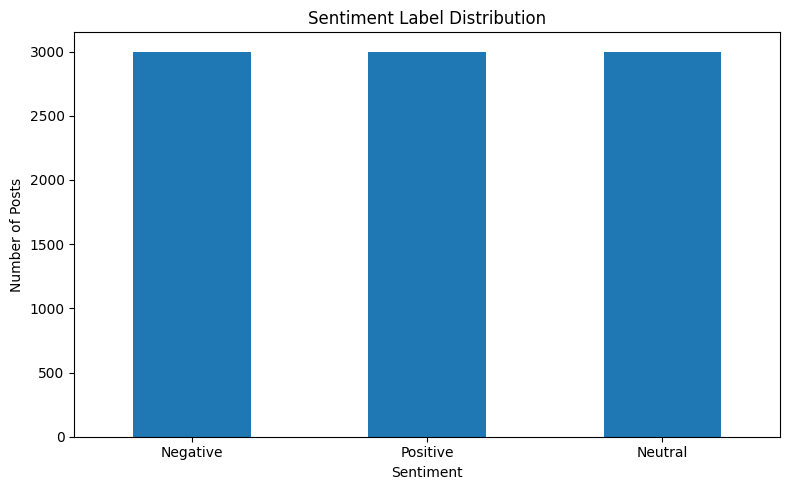

In [22]:
# Visualize sentiment distribution

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind="bar")

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interpretation

The sentiment labels are perfectly balanced across the dataset:

- Negative: 3,000 records (33.33%)
- Neutral: 3,000 records (33.33%)
- Positive: 3,000 records (33.33%)

Each sentiment class represents exactly one-third of the 9,000 observations.
Therefore, there is no observed class imbalance in the sentiment target.

This balanced distribution provides an appropriate basis for multiclass
sentiment classification and reduces the risk that overall accuracy is
dominated by a particular sentiment class.

Model performance will nevertheless be evaluated using precision, recall,
and F1-score alongside accuracy to assess class-level behaviour.

### 5.2 Topic Distribution

In [23]:
# Topic distribution

topic_counts = df["topic_category"].value_counts()

topic_summary = pd.DataFrame({
    "Count": topic_counts,
    "Percentage": (
        topic_counts / len(df) * 100
    ).round(2)
})

display(topic_summary)

,Count,Percentage
topic_category,,
Community_Discussion,7752,86.13
Technical_Issues,815,9.06
Feature_Feedback,297,3.30
Account_Security,136,1.51


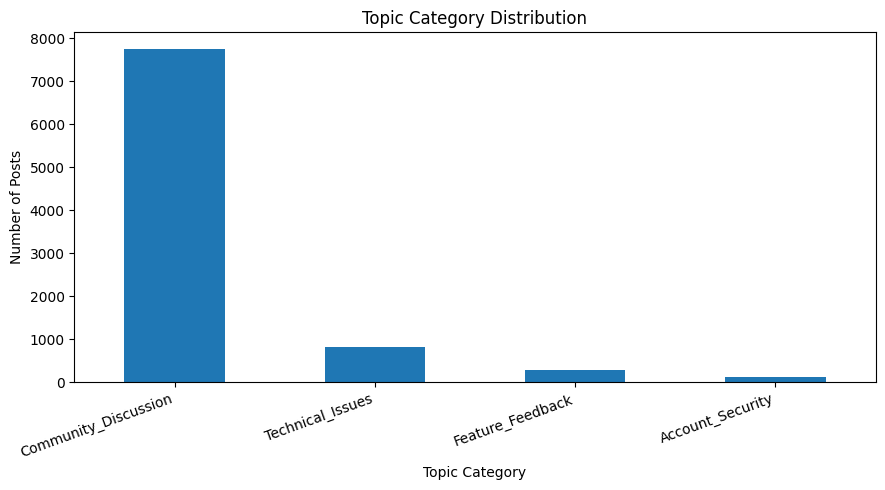

In [24]:
# Visualize topic distribution

plt.figure(figsize=(9, 5))

topic_counts.plot(kind="bar")

plt.title("Topic Category Distribution")
plt.xlabel("Topic Category")
plt.ylabel("Number of Posts")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

#### Interpretation

The topic distribution is highly imbalanced across the dataset:

- **Community_Discussion:** 7,752 records (86.13%)
- **Technical_Issues:** 815 records (9.06%)
- **Feature_Feedback:** 297 records (3.30%)
- **Account_Security:** 136 records (1.51%)

Community_Discussion dominates the dataset, accounting for more than four-fifths of all observations. The remaining three categories are comparatively underrepresented, with Account_Security being the smallest class.

This imbalance means that overall accuracy alone would be misleading for topic classification. A model could achieve high accuracy by performing well on Community_Discussion while performing poorly on the minority topics.

Therefore, topic-classification performance should be assessed using per-class precision, recall, F1-score, macro F1, and a confusion matrix, with particular attention to the minority categories.

### 5.3 Text Length Analysis

In [25]:
# Create text-length features for exploratory analysis

df["character_count"] = df["post_text"].str.len()
df["word_count"] = df["post_text"].str.split().str.len()

display(
    df[["character_count", "word_count"]].describe().round(2)
)

,character_count,word_count
count,9000.00,9000.00
mean,107.99,19.47
std,26.10,4.93
min,25.00,4.00
25%,91.00,16.00
50%,113.00,20.00
75%,129.00,23.00
max,180.00,35.00


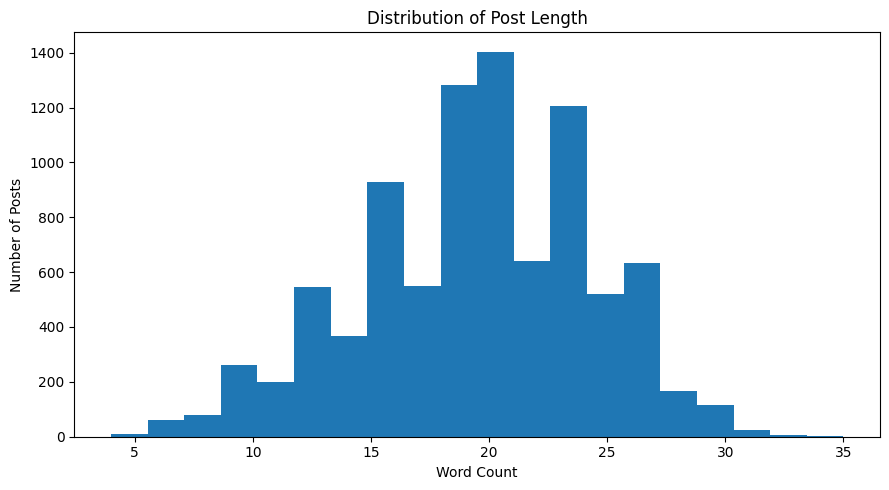

In [26]:
# Distribution of word counts

plt.figure(figsize=(9, 5))

plt.hist(df["word_count"], bins=20)

plt.title("Distribution of Post Length")
plt.xlabel("Word Count")
plt.ylabel("Number of Posts")
plt.tight_layout()
plt.show()

In [27]:
# Text length by sentiment

display(
    df.groupby("sentiment_label")["word_count"]
      .agg(["count", "mean", "median", "min", "max"])
      .round(2)
)

,count,mean,median,min,max
sentiment_label,,,,,
Negative,3000,20.19,21.0,5,35
Neutral,3000,18.99,19.0,4,32
Positive,3000,19.24,20.0,5,34


### 5.4 Sentiment × Topic Relationship

In [28]:
# Sentiment-topic cross-tabulation

sentiment_topic = pd.crosstab(
    df["sentiment_label"],
    df["topic_category"]
)

display(sentiment_topic)

topic_category,Account_Security,Community_Discussion,Feature_Feedback,Technical_Issues
sentiment_label,,,,
Negative,34,2583,119,264
Neutral,47,2623,104,226
Positive,55,2546,74,325


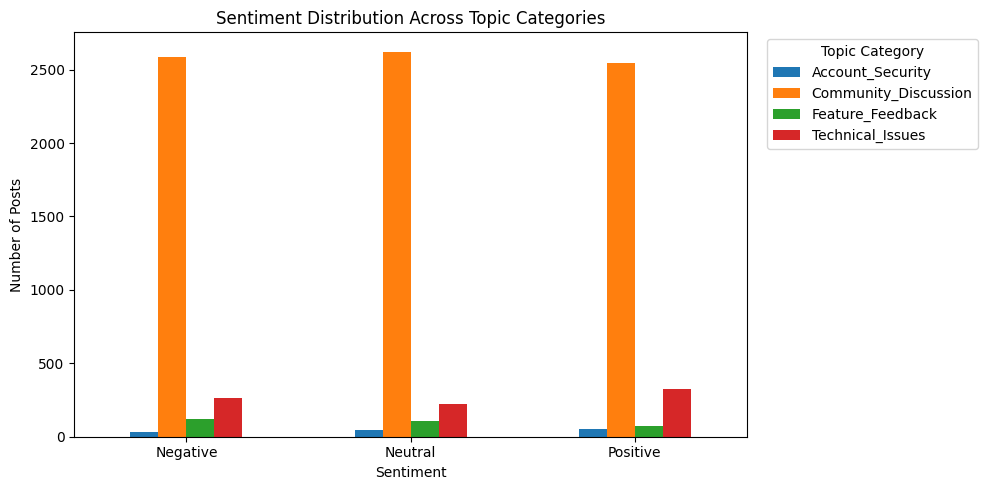

In [29]:
# Visualize sentiment-topic relationship

sentiment_topic.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sentiment Distribution Across Topic Categories")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")
plt.xticks(rotation=0)
plt.legend(title="Topic Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.5 Text Examples by Label

In [30]:
# Inspect representative examples from each sentiment class

for sentiment in df["sentiment_label"].unique():
    print(f"\n{'=' * 70}")
    print(f"SENTIMENT: {sentiment}")
    print("=" * 70)

    display(
        df[df["sentiment_label"] == sentiment]
        [["post_text", "topic_category"]]
        .sample(min(5, len(df[df["sentiment_label"] == sentiment])),
                random_state=RANDOM_STATE)
    )


SENTIMENT: Negative


,post_text,topic_category
5497,@user @user Remember the IRA? They're Christia...,Community_Discussion
3680,Never understand people who keep Kanye West an...,Community_Discussion
5540,6th floor. David Mack assaults Jennifer Lawren...,Community_Discussion
755,"""More meta-textually, Ant-Man may be the worst...",Community_Discussion
7548,"@user oh for goodness sake, BBC seems to want ...",Community_Discussion



SENTIMENT: Positive


,post_text,topic_category
5406,Off to see Jurassic World tomorrow at the cine...,Community_Discussion
3475,@user @user I\u2019m guessing the night of the...,Community_Discussion
5450,David wright 1st game back and he goes deep,Community_Discussion
737,Most Anticipated mixtape of the year @user THE...,Community_Discussion
7462,@user well its my favorite 4th doctor story an...,Community_Discussion



SENTIMENT: Neutral


,post_text,topic_category
5318,"""And, last night, I tweeted this article I wro...",Community_Discussion
3588,@user @user I'm away at Write Around the Murra...,Community_Discussion
5346,Last game for Jr. High Bearcats/7th grade. On ...,Community_Discussion
786,"""Ladies! Due to a scheduling conflict with our...",Community_Discussion
7556,Smart money says Rick Perry will be the first ...,Feature_Feedback


In [31]:
# Inspect representative examples from each topic

for topic in df["topic_category"].unique():
    print(f"\n{'=' * 70}")
    print(f"TOPIC: {topic}")
    print("=" * 70)

    display(
        df[df["topic_category"] == topic]
        [["post_text", "sentiment_label"]]
        .sample(min(5, len(df[df["topic_category"] == topic])),
                random_state=RANDOM_STATE)
    )


TOPIC: Community_Discussion


,post_text,sentiment_label
5881,Nirvana - All Apologies #RadioBaro In the s...,Neutral
6470,my iTunes is playing sun is shining by bob mar...,Negative
1903,"""Nice to see the neighbours rocking a bit of D...",Neutral
7918,This statement may seem heartless but the refu...,Negative
4516,@user lol I'm supposed to be going to Milan to...,Positive



TOPIC: Account_Security


,post_text,sentiment_label
4226,"@user Thanks, Israel! The base-band version wi...",Positive
2430,"""This female said Kirko Bangz will be her nigg...",Neutral
3252,Zac Brown Band is going to be the best country...,Positive
2186,I'm just excited to work the Zac Brown Band co...,Positive
8609,she gave me her Netflix password . . . I've cr...,Positive



TOPIC: Feature_Feedback


,post_text,sentiment_label
5221,Jenson Button may be worrying about keeping hi...,Negative
6664,Look forward to watching Alex Reid on Celebrit...,Positive
1997,"""My Passion: NHK announces hosts for the 63rd ...",Neutral
4844,"""Quote-We must fight the evil trio of America,...",Negative
182,@user any odds on louis saha to score the winn...,Neutral



TOPIC: Technical_Issues


,post_text,sentiment_label
2036,"So here I am, 00:30 in the morning sat looking...",Positive
3193,If you haven\u2019t seen your Good Giving Guid...,Positive
4412,"""Kanye West would make a better president than...",Positive
2322,"""Forgetting about the money, I'd just be so ha...",Positive
7320,Chris Brown for the 5th touchdown of the night...,Positive


### 5.6 EDA Summary

The exploratory analysis provides the following key observations:

1. **Sentiment distribution:** The dataset contains 3,000 Negative, 3,000 Neutral, and 3,000 Positive records, resulting in a perfectly balanced sentiment distribution.

2. **Topic distribution:** The topic variable is highly imbalanced. Community_Discussion accounts for 86.13% of the dataset, while Technical_Issues, Feature_Feedback, and Account_Security account for 9.06%, 3.30%, and 1.51%, respectively.

3. **Text length:** Posts contain an average of 19.47 words and 107.99 characters. Word counts range from 4 to 35, indicating relatively short and consistently sized social-media-style text.

4. **Sentiment and text length:** Negative posts have the highest median word count (21), compared with Positive posts (20) and Neutral posts (19). The differences are relatively small, indicating that sentiment is not strongly separated by text length alone.

5. **Sentiment–topic relationship:** Community_Discussion contains the majority of observations across all three sentiment classes. Technical_Issues contains more Positive posts (325) than Negative (264) or Neutral (226), while Feature_Feedback contains more Negative posts (119) than Positive (74). Account_Security remains the smallest topic across all sentiment classes.

6. **Modelling implications:** The balanced sentiment target provides a suitable basis for sentiment classification. However, the severe topic imbalance requires class-level evaluation metrics rather than relying on accuracy alone for topic classification.

Overall, the EDA indicates that the dataset is structurally suitable for NLP modelling, while the major modelling consideration is the strong imbalance in topic categories. The next stage will therefore focus on applying a consistent text preprocessing pipeline before model development.

## 6. Text Preprocessing

### 6.1 Text Cleaning

In [33]:
def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove user mentions
    text = re.sub(r"@\w+", " ", text)

    # Keep hashtag words but remove the # symbol
    text = re.sub(r"#(\w+)", r"\1", text)

    # Keep letters and digits; remove punctuation/special symbols
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

df["clean_text"] = df["post_text"].apply(clean_text)

display(df[["post_text", "clean_text"]].head(10))

,post_text,clean_text
0,some1 come wait in line with me Thursday at 3@...,some1 come wait in line with me thursday at 3 ...
1,Mancity strikers Aguero and Dzeko you better t...,mancity strikers aguero and dzeko you better t...
2,Would you like to join us at our annual gala a...,would you like to join us at our annual gala a...
3,"""Sicily may form grand coalition, Italian UDC ...",sicily may form grand coalition italian udc pa...
4,@user @user If the comment was in reference to...,if the comment was in reference to the charlie...
5,@user @user aaaah. Nokia used to make the Best...,aaaah nokia used to make the best phone camera...
6,Curtis Painter was asked in interviews today i...,curtis painter was asked in interviews today i...
7,"""When gaza march out pon the battlefield it's ...",when gaza march out pon the battlefield it s a...
8,"""WLS Quick Look """" Caitlyn Jenner - 1st Public...",wls quick look caitlyn jenner 1st public reuni...
9,"""1st game played under Solar Powered floodligh...",1st game played under solar powered floodlight...


#### 6.1 Text Cleaning

The preprocessing step removes structural noise while preserving potentially meaningful textual information.

- Convert text to lowercase to normalize vocabulary.
- Remove URLs because they often act as noisy identifiers rather than meaningful text.
- Remove user mentions while retaining the surrounding content.
- Remove the `#` symbol from hashtags while preserving the hashtag word.
- Remove punctuation and special symbols while preserving alphanumeric characters.
- Normalize repeated whitespace.

Alphanumeric characters are intentionally preserved because social-media text may contain meaningful expressions such as product names, model numbers, abbreviations, and informal spellings.

### 6.2 Stopword Handling

In [34]:
print("Stopword removal: Not applied")
print("Reason: Function words may provide useful contextual information in short social-media text.")

Stopword removal: Not applied
Reason: Function words may provide useful contextual information in short social-media text.


### 6.3 Preprocessing Validation

In [35]:
print("Original text examples:")
display(df["post_text"].head(5))

print("\nCleaned text examples:")
display(df["clean_text"].head(5))

print("\nMissing values after preprocessing:")
print(df["clean_text"].isna().sum())

print("\nEmpty cleaned texts:")
print((df["clean_text"].str.strip() == "").sum())

Original text examples:


,post_text
0,some1 come wait in line with me Thursday at 3@...
1,Mancity strikers Aguero and Dzeko you better t...
2,Would you like to join us at our annual gala a...
3,"""Sicily may form grand coalition, Italian UDC ..."
4,@user @user If the comment was in reference to...



Cleaned text examples:


,clean_text
0,some1 come wait in line with me thursday at 3 ...
1,mancity strikers aguero and dzeko you better t...
2,would you like to join us at our annual gala a...
3,sicily may form grand coalition italian udc pa...
4,if the comment was in reference to the charlie...



Missing values after preprocessing:
0

Empty cleaned texts:
0


### 6.4 Final Text Representation

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF vectorizer configured successfully.")
print("N-grams: Unigrams + Bigrams")
print("Minimum document frequency: 2")
print("Maximum document frequency: 95%")

TF-IDF vectorizer configured successfully.
N-grams: Unigrams + Bigrams
Minimum document frequency: 2
Maximum document frequency: 95%


## 7. Train-Test Split

### 7.1 Train-Test Split

Because the dataset contains repeated text entries, a group-aware split is used to reduce the risk of identical texts appearing in both the training and test sets.

The cleaned text is used as the grouping variable, ensuring that all identical text entries remain within the same split.

An 75:25 train-test split is used for model development and evaluation.

### 7.2 Group-Aware Split

In [38]:
from sklearn.model_selection import GroupShuffleSplit

X = df["clean_text"]
y_sentiment = df["sentiment_label"]
y_topic = df["topic_category"]
groups = df["clean_text"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(gss.split(X, y_sentiment, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_sentiment_train = y_sentiment.iloc[train_idx]
y_sentiment_test = y_sentiment.iloc[test_idx]

y_topic_train = y_topic.iloc[train_idx]
y_topic_test = y_topic.iloc[test_idx]

print(f"Training samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

Training samples: 6,773
Test samples: 2,227


### 7.3 Split Validation

In [39]:
print("Training set:")
print(f"  Samples: {len(X_train):,}")
print(f"  Unique texts: {X_train.nunique():,}")

print("\nTest set:")
print(f"  Samples: {len(X_test):,}")
print(f"  Unique texts: {X_test.nunique():,}")

overlap = set(X_train) & set(X_test)

print(f"\nIdentical texts appearing in both sets: {len(overlap)}")

Training set:
  Samples: 6,773
  Unique texts: 5,922

Test set:
  Samples: 2,227
  Unique texts: 1,975

Identical texts appearing in both sets: 0


In [40]:
print("Sentiment distribution — Training:")
display(y_sentiment_train.value_counts(normalize=True).mul(100).round(2))

print("\nSentiment distribution — Test:")
display(y_sentiment_test.value_counts(normalize=True).mul(100).round(2))

print("\nTopic distribution — Training:")
display(y_topic_train.value_counts(normalize=True).mul(100).round(2))

print("\nTopic distribution — Test:")
display(y_topic_test.value_counts(normalize=True).mul(100).round(2))

Sentiment distribution — Training:


,proportion
sentiment_label,
Neutral,33.50
Positive,33.29
Negative,33.21



Sentiment distribution — Test:


,proportion
sentiment_label,
Negative,33.72
Positive,33.45
Neutral,32.82



Topic distribution — Training:


,proportion
topic_category,
Community_Discussion,86.27
Technical_Issues,8.87
Feature_Feedback,3.38
Account_Security,1.48



Topic distribution — Test:


,proportion
topic_category,
Community_Discussion,85.72
Technical_Issues,9.61
Feature_Feedback,3.05
Account_Security,1.62


### 7.4 Split Decision

The 75:25 group-aware split maintains similar class distributions across the training and test sets.

For sentiment, the three classes remain closely balanced in both sets, with each class representing approximately one-third of the observations. The largest difference between training and test proportions is less than 1 percentage point.

For topic, Community_Discussion remains the dominant category in both sets (86.27% in training and 85.72% in test). The remaining topic proportions also remain relatively close between the two sets.

These results indicate that the split has not introduced a substantial distribution shift between training and test data. Combined with zero identical texts across the two sets, the split provides a suitable basis for unbiased model evaluation.

The 75:25 group-aware split is therefore retained for subsequent modelling.

## 8. Baseline Evaluation

### 8.1 TF-IDF Feature Construction

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=False,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF feature construction completed.")
print(f"Training matrix shape: {X_train_tfidf.shape}")
print(f"Test matrix shape: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf.vocabulary_):,}")

TF-IDF feature construction completed.
Training matrix shape: (6773, 24481)
Test matrix shape: (2227, 24481)
Vocabulary size: 24,481


### 8.2 Baseline Model Training

In [42]:
from sklearn.linear_model import LogisticRegression

sentiment_baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

topic_baseline = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

sentiment_baseline.fit(X_train_tfidf, y_sentiment_train)
topic_baseline.fit(X_train_tfidf, y_topic_train)

print("Baseline models trained successfully.")

Baseline models trained successfully.


### 8.3 Baseline Evaluation Metrics

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
sentiment_pred = sentiment_baseline.predict(X_test_tfidf)
topic_pred = topic_baseline.predict(X_test_tfidf)

# Sentiment metrics
sentiment_metrics = {
    "Accuracy": accuracy_score(y_sentiment_test, sentiment_pred),
    "Precision (Macro)": precision_score(
        y_sentiment_test, sentiment_pred, average="macro", zero_division=0
    ),
    "Recall (Macro)": recall_score(
        y_sentiment_test, sentiment_pred, average="macro", zero_division=0
    ),
    "F1 (Macro)": f1_score(
        y_sentiment_test, sentiment_pred, average="macro", zero_division=0
    ),
    "F1 (Weighted)": f1_score(
        y_sentiment_test, sentiment_pred, average="weighted", zero_division=0
    )
}

# Topic metrics
topic_metrics = {
    "Accuracy": accuracy_score(y_topic_test, topic_pred),
    "Precision (Macro)": precision_score(
        y_topic_test, topic_pred, average="macro", zero_division=0
    ),
    "Recall (Macro)": recall_score(
        y_topic_test, topic_pred, average="macro", zero_division=0
    ),
    "F1 (Macro)": f1_score(
        y_topic_test, topic_pred, average="macro", zero_division=0
    ),
    "F1 (Weighted)": f1_score(
        y_topic_test, topic_pred, average="weighted", zero_division=0
    )
}

print("SENTIMENT BASELINE")
display(pd.DataFrame(sentiment_metrics, index=["Score"]).round(4))

print("\nTOPIC BASELINE")
display(pd.DataFrame(topic_metrics, index=["Score"]).round(4))

SENTIMENT BASELINE


,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted)
Score,0.5712,0.571,0.5707,0.5708,0.5713



TOPIC BASELINE


,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted)
Score,0.8828,0.6575,0.3339,0.3723,0.8437


### 8.4 Classification Reports + Confusion Matrices

In [44]:
print("=== SENTIMENT CLASSIFICATION REPORT ===")
print(classification_report(
    y_sentiment_test,
    sentiment_pred,
    zero_division=0
))

print("\n=== TOPIC CLASSIFICATION REPORT ===")
print(classification_report(
    y_topic_test,
    topic_pred,
    zero_division=0
))

=== SENTIMENT CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.61      0.60      0.60       751
     Neutral       0.50      0.50      0.50       731
    Positive       0.60      0.61      0.61       745

    accuracy                           0.57      2227
   macro avg       0.57      0.57      0.57      2227
weighted avg       0.57      0.57      0.57      2227


=== TOPIC CLASSIFICATION REPORT ===
                      precision    recall  f1-score   support

    Account_Security       0.75      0.08      0.15        36
Community_Discussion       0.88      1.00      0.94      1909
    Feature_Feedback       0.00      0.00      0.00        68
    Technical_Issues       1.00      0.25      0.40       214

            accuracy                           0.88      2227
           macro avg       0.66      0.33      0.37      2227
        weighted avg       0.86      0.88      0.84      2227



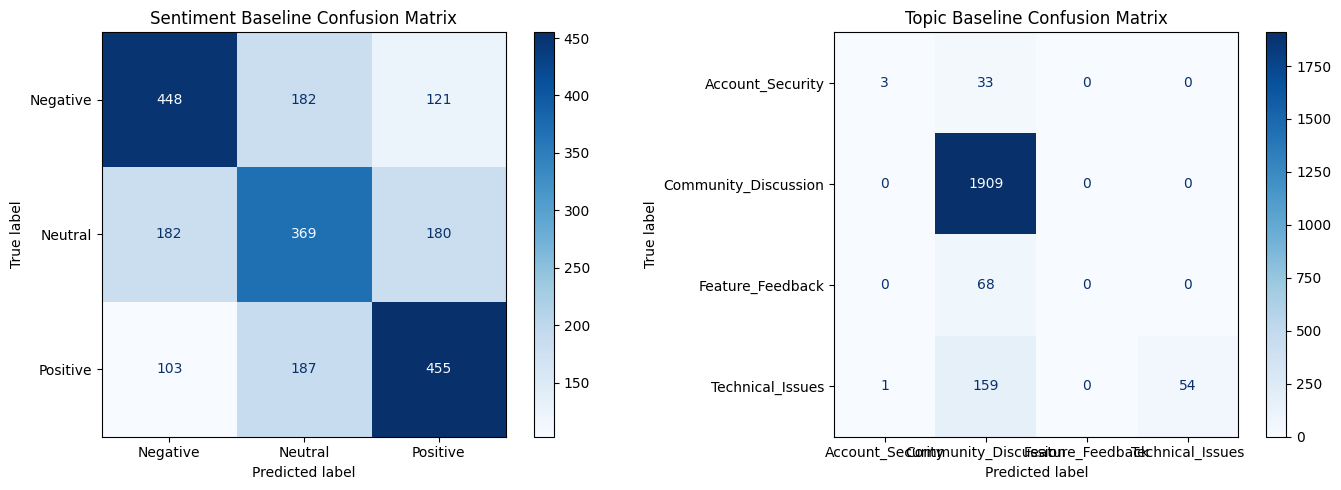

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_sentiment_test,
    sentiment_pred,
    ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("Sentiment Baseline Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_topic_test,
    topic_pred,
    ax=axes[1],
    cmap="Blues"
)
axes[1].set_title("Topic Baseline Confusion Matrix")

plt.tight_layout()
plt.show()

### 8.5 Baseline Interpretation

The TF-IDF + Logistic Regression baseline produces different results for the two classification tasks.

**Sentiment classification:**

* The sentiment model achieves 57.12% accuracy and a macro F1-score of 0.5708. Performance is relatively consistent across the three sentiment classes, with F1-scores of 0.60 for Negative, 0.50 for Neutral, and 0.61 for Positive.

* The confusion matrix shows that Neutral posts are frequently confused with both Negative and Positive posts. This indicates that sentiment boundaries are less distinct for Neutral content, making it the most difficult sentiment class for the baseline model.

**Topic classification:**

* The topic model achieves 88.28% accuracy, but its macro F1-score is considerably lower at 0.3723. This difference is explained by the strong topic imbalance identified during EDA.

* Community_Discussion is classified effectively, with a recall of 1.00 and an F1-score of 0.94. However, the minority classes are not handled equally well. Account_Security has a recall of 0.08, Feature_Feedback has an F1-score of 0.00, and Technical_Issues has a recall of 0.25.

* The topic confusion matrix shows that many minority-topic posts are predicted as Community_Discussion. Therefore, the high overall accuracy is largely influenced by the dominant Community_Discussion class and does not represent balanced performance across all topic categories.

* Overall, the baseline establishes a useful reference point but leaves substantial scope for improvement, particularly in distinguishing Neutral sentiment and the minority topic categories.

## 9. Improved TF-IDF + Logistic Regression

### 9.1 Validation Split for Model Tuning

The baseline model established TF-IDF with Logistic Regression as the initial benchmark. This section investigates whether its performance can be improved while retaining the same lightweight modelling approach.

Model tuning is performed using a validation subset derived from the training data. The original test set is kept separate for final evaluation.

The tuning process focuses on TF-IDF configuration and Logistic Regression regularization and class weighting.

In [48]:
from sklearn.model_selection import GroupShuffleSplit

# Create a validation split from the training data
gss_val = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE
)

train_sub_idx, val_idx = next(
    gss_val.split(
        X_train,
        y_sentiment_train,
        groups=X_train
    )
)

X_subtrain = X_train.iloc[train_sub_idx]
X_val = X_train.iloc[val_idx]

y_sentiment_subtrain = y_sentiment_train.iloc[train_sub_idx]
y_sentiment_val = y_sentiment_train.iloc[val_idx]

y_topic_subtrain = y_topic_train.iloc[train_sub_idx]
y_topic_val = y_topic_train.iloc[val_idx]

print(f"Sub-training samples: {len(X_subtrain):,}")
print(f"Validation samples: {len(X_val):,}")
print(f"Identical texts across sub-training and validation: "
      f"{len(set(X_subtrain) & set(X_val))}")

Sub-training samples: 5,061
Validation samples: 1,712
Identical texts across sub-training and validation: 0


### 9.2 TF-IDF Configuration Tuning

In [47]:
tfidf_configs = {
    "TFIDF_A": {
        "ngram_range": (1, 1),
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": True
    },
    "TFIDF_B": {
        "ngram_range": (1, 2),
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": True
    },
    "TFIDF_C": {
        "ngram_range": (1, 2),
        "min_df": 1,
        "max_df": 0.95,
        "sublinear_tf": True
    },
    "TFIDF_D": {
        "ngram_range": (1, 3),
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": True
    }
}

tfidf_results = []

for name, params in tfidf_configs.items():

    vectorizer = TfidfVectorizer(**params)

    X_sub_tfidf = vectorizer.fit_transform(X_subtrain)
    X_val_tfidf = vectorizer.transform(X_val)

    model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    # Sentiment
    model.fit(X_sub_tfidf, y_sentiment_subtrain)
    pred = model.predict(X_val_tfidf)

    sentiment_f1 = f1_score(
        y_sentiment_val,
        pred,
        average="macro"
    )

    # Topic
    model.fit(X_sub_tfidf, y_topic_subtrain)
    pred = model.predict(X_val_tfidf)

    topic_f1 = f1_score(
        y_topic_val,
        pred,
        average="macro"
    )

    tfidf_results.append({
        "Configuration": name,
        "Features": X_sub_tfidf.shape[1],
        "Sentiment Macro F1": sentiment_f1,
        "Topic Macro F1": topic_f1
    })

tfidf_results_df = pd.DataFrame(tfidf_results)

display(
    tfidf_results_df.sort_values(
        "Topic Macro F1",
        ascending=False
    ).round(4)
)

,Configuration,Features,Sentiment Macro F1,Topic Macro F1
0,TFIDF_A,5954,0.5985,0.3890
1,TFIDF_B,20120,0.5888,0.3351
3,TFIDF_D,32111,0.5823,0.3286
2,TFIDF_C,66781,0.5854,0.2956


### 9.3 Logistic Regression Tuning

In [49]:
# Select the best TF-IDF configuration based on validation performance
best_tfidf_name = (
    tfidf_results_df
    .sort_values("Topic Macro F1", ascending=False)
    .iloc[0]["Configuration"]
)

best_tfidf_params = tfidf_configs[best_tfidf_name]

print("Selected TF-IDF configuration:", best_tfidf_name)
print(best_tfidf_params)

# Fit selected TF-IDF on sub-training data
best_vectorizer = TfidfVectorizer(**best_tfidf_params)

X_sub_tfidf = best_vectorizer.fit_transform(X_subtrain)
X_val_tfidf = best_vectorizer.transform(X_val)

lr_configs = [
    {"C": 0.5, "class_weight": None},
    {"C": 1.0, "class_weight": None},
    {"C": 2.0, "class_weight": None},
    {"C": 5.0, "class_weight": None},
    {"C": 1.0, "class_weight": "balanced"},
    {"C": 2.0, "class_weight": "balanced"},
    {"C": 5.0, "class_weight": "balanced"}
]

lr_results = []

for config in lr_configs:

    # Sentiment
    sentiment_model = LogisticRegression(
        C=config["C"],
        class_weight=config["class_weight"],
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    sentiment_model.fit(X_sub_tfidf, y_sentiment_subtrain)
    sentiment_pred_val = sentiment_model.predict(X_val_tfidf)

    sentiment_f1 = f1_score(
        y_sentiment_val,
        sentiment_pred_val,
        average="macro"
    )

    # Topic
    topic_model = LogisticRegression(
        C=config["C"],
        class_weight=config["class_weight"],
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    topic_model.fit(X_sub_tfidf, y_topic_subtrain)
    topic_pred_val = topic_model.predict(X_val_tfidf)

    topic_f1 = f1_score(
        y_topic_val,
        topic_pred_val,
        average="macro"
    )

    lr_results.append({
        "C": config["C"],
        "Class Weight": config["class_weight"],
        "Sentiment Macro F1": sentiment_f1,
        "Topic Macro F1": topic_f1
    })

lr_results_df = pd.DataFrame(lr_results)

display(
    lr_results_df.sort_values(
        "Topic Macro F1",
        ascending=False
    ).round(4)
)

Selected TF-IDF configuration: TFIDF_A
{'ngram_range': (1, 1), 'min_df': 2, 'max_df': 0.95, 'sublinear_tf': True}


,C,Class Weight,Sentiment Macro F1,Topic Macro F1
6,5.0,balanced,0.5845,0.5811
5,2.0,balanced,0.5974,0.5682
4,1.0,balanced,0.5936,0.5604
3,5.0,None,0.5846,0.4785
2,2.0,None,0.5919,0.4589
1,1.0,None,0.5951,0.3980
0,0.5,None,0.5914,0.2947


### 9.4 Final Improved Model Evaluation

In [50]:
# Final TF-IDF configuration selected from validation
final_tfidf = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

# Fit only on the complete training data
X_train_final_tfidf = final_tfidf.fit_transform(X_train)
X_test_final_tfidf = final_tfidf.transform(X_test)

print("Final TF-IDF representation created.")
print(f"Training matrix shape: {X_train_final_tfidf.shape}")
print(f"Test matrix shape: {X_test_final_tfidf.shape}")
print(f"Vocabulary size: {len(final_tfidf.vocabulary_):,}")

# Final sentiment model
final_sentiment_model = LogisticRegression(
    C=2.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Final topic model
final_topic_model = LogisticRegression(
    C=5.0,
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train
final_sentiment_model.fit(
    X_train_final_tfidf,
    y_sentiment_train
)

final_topic_model.fit(
    X_train_final_tfidf,
    y_topic_train
)

# Test predictions
final_sentiment_pred = final_sentiment_model.predict(
    X_test_final_tfidf
)

final_topic_pred = final_topic_model.predict(
    X_test_final_tfidf
)

print("\nFinal improved models trained successfully.")

Final TF-IDF representation created.
Training matrix shape: (6773, 6865)
Test matrix shape: (2227, 6865)
Vocabulary size: 6,865

Final improved models trained successfully.


In [51]:
# Sentiment evaluation
sentiment_final_metrics = {
    "Accuracy": accuracy_score(
        y_sentiment_test, final_sentiment_pred
    ),
    "Precision (Macro)": precision_score(
        y_sentiment_test,
        final_sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "Recall (Macro)": recall_score(
        y_sentiment_test,
        final_sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "F1 (Macro)": f1_score(
        y_sentiment_test,
        final_sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "F1 (Weighted)": f1_score(
        y_sentiment_test,
        final_sentiment_pred,
        average="weighted",
        zero_division=0
    )
}

# Topic evaluation
topic_final_metrics = {
    "Accuracy": accuracy_score(
        y_topic_test, final_topic_pred
    ),
    "Precision (Macro)": precision_score(
        y_topic_test,
        final_topic_pred,
        average="macro",
        zero_division=0
    ),
    "Recall (Macro)": recall_score(
        y_topic_test,
        final_topic_pred,
        average="macro",
        zero_division=0
    ),
    "F1 (Macro)": f1_score(
        y_topic_test,
        final_topic_pred,
        average="macro",
        zero_division=0
    ),
    "F1 (Weighted)": f1_score(
        y_topic_test,
        final_topic_pred,
        average="weighted",
        zero_division=0
    )
}

print("IMPROVED SENTIMENT MODEL")
display(
    pd.DataFrame(
        sentiment_final_metrics,
        index=["Score"]
    ).round(4)
)

print("\nIMPROVED TOPIC MODEL")
display(
    pd.DataFrame(
        topic_final_metrics,
        index=["Score"]
    ).round(4)
)

IMPROVED SENTIMENT MODEL


,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted)
Score,0.5734,0.5731,0.573,0.573,0.5735



IMPROVED TOPIC MODEL


,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted)
Score,0.9273,0.8272,0.5796,0.6591,0.9187


In [52]:
print("=== IMPROVED SENTIMENT CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_sentiment_test,
        final_sentiment_pred,
        zero_division=0
    )
)

print("\n=== IMPROVED TOPIC CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_topic_test,
        final_topic_pred,
        zero_division=0
    )
)

=== IMPROVED SENTIMENT CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.61      0.60      0.60       751
     Neutral       0.51      0.51      0.51       731
    Positive       0.61      0.61      0.61       745

    accuracy                           0.57      2227
   macro avg       0.57      0.57      0.57      2227
weighted avg       0.57      0.57      0.57      2227


=== IMPROVED TOPIC CLASSIFICATION REPORT ===
                      precision    recall  f1-score   support

    Account_Security       0.86      0.33      0.48        36
Community_Discussion       0.94      0.99      0.96      1909
    Feature_Feedback       0.61      0.32      0.42        68
    Technical_Issues       0.91      0.67      0.77       214

            accuracy                           0.93      2227
           macro avg       0.83      0.58      0.66      2227
        weighted avg       0.92      0.93      0.92      2227



### 9.5 Improved Model Interpretation

* The improved TF-IDF + Logistic Regression models were selected using a validation-based tuning process and then evaluated on the untouched test set.

* For sentiment classification, the improved model achieves an accuracy of 57.34% and a macro F1-score of 0.5730, compared with 57.12% accuracy and 0.5708 macro F1 for the baseline. This represents only a small improvement, indicating that changing the TF-IDF configuration and applying class weighting provides limited additional benefit for sentiment classification.

* The class-level results remain relatively consistent across the three sentiment categories. Neutral remains the most difficult class, with an F1-score of 0.51, while Negative and Positive achieve F1-scores of 0.60 and 0.61 respectively.

* For topic classification, the improvement is substantially larger. Accuracy increases from 88.28% in the baseline to 92.73%, while macro F1 increases from 0.3723 to 0.6591. This indicates that class weighting substantially improves the model's ability to identify minority topic categories rather than simply predicting the dominant Community_Discussion class.

* The improved topic model achieves F1-scores of 0.48 for Account_Security, 0.96 for Community_Discussion, 0.42 for Feature_Feedback, and 0.77 for Technical_Issues. Although minority-class performance has improved considerably, Feature_Feedback and Account_Security remain more difficult to classify than the dominant category.

* The final TF-IDF representation contains 6,865 features, compared with 24,481 features in the baseline. The reduction results from selecting a unigram-only representation, which also produced better validation performance than the tested bigram and trigram configurations.

* Overall, the tuning experiment demonstrates that a relatively simple TF-IDF + Logistic Regression approach can substantially improve topic classification when class imbalance is explicitly addressed. However, the limited improvement in sentiment classification suggests that additional modelling approaches should be investigated.

## 10. Lightweight Model Benchmarking

### 10.1 VADER Sentiment Baseline

In [53]:
# Install and import VADER
!pip -q install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = analyzer.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

vader_pred = X_test.index.map(
    lambda i: vader_predict(df.loc[i, "post_text"])
)

print("VADER sentiment predictions generated.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.1 MB/s eta 0:00:00
VADER sentiment predictions generated.


In [54]:
vader_metrics = {
    "Accuracy": accuracy_score(
        y_sentiment_test, vader_pred
    ),
    "Precision (Macro)": precision_score(
        y_sentiment_test,
        vader_pred,
        average="macro",
        zero_division=0
    ),
    "Recall (Macro)": recall_score(
        y_sentiment_test,
        vader_pred,
        average="macro",
        zero_division=0
    ),
    "F1 (Macro)": f1_score(
        y_sentiment_test,
        vader_pred,
        average="macro",
        zero_division=0
    ),
    "F1 (Weighted)": f1_score(
        y_sentiment_test,
        vader_pred,
        average="weighted",
        zero_division=0
    )
}

display(
    pd.DataFrame(vader_metrics, index=["VADER"]).round(4)
)

print("\n=== VADER CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_sentiment_test,
        vader_pred,
        zero_division=0
    )
)

,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),F1 (Weighted)
VADER,0.5819,0.5876,0.5809,0.5753,0.5762



=== VADER CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.69      0.59      0.64       751
     Neutral       0.53      0.41      0.47       731
    Positive       0.54      0.74      0.62       745

    accuracy                           0.58      2227
   macro avg       0.59      0.58      0.58      2227
weighted avg       0.59      0.58      0.58      2227



### 10.2 Multinomial Naive Bayes

In [55]:
from sklearn.naive_bayes import MultinomialNB

nb_sentiment = MultinomialNB()
nb_topic = MultinomialNB()

nb_sentiment.fit(
    X_train_final_tfidf,
    y_sentiment_train
)

nb_topic.fit(
    X_train_final_tfidf,
    y_topic_train
)

nb_sentiment_pred = nb_sentiment.predict(
    X_test_final_tfidf
)

nb_topic_pred = nb_topic.predict(
    X_test_final_tfidf
)

print("Multinomial Naive Bayes models trained successfully.")

Multinomial Naive Bayes models trained successfully.


In [56]:
nb_results = {
    "Sentiment Accuracy": accuracy_score(
        y_sentiment_test, nb_sentiment_pred
    ),
    "Sentiment Macro F1": f1_score(
        y_sentiment_test,
        nb_sentiment_pred,
        average="macro"
    ),
    "Topic Accuracy": accuracy_score(
        y_topic_test, nb_topic_pred
    ),
    "Topic Macro F1": f1_score(
        y_topic_test,
        nb_topic_pred,
        average="macro"
    )
}

display(
    pd.DataFrame(nb_results, index=["Multinomial NB"]).round(4)
)

,Sentiment Accuracy,Sentiment Macro F1,Topic Accuracy,Topic Macro F1
Multinomial NB,0.5712,0.5653,0.8572,0.2308


### 10.3 Linear SVM

In [57]:
from sklearn.svm import LinearSVC

svm_sentiment = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_topic = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

svm_sentiment.fit(
    X_train_final_tfidf,
    y_sentiment_train
)

svm_topic.fit(
    X_train_final_tfidf,
    y_topic_train
)

svm_sentiment_pred = svm_sentiment.predict(
    X_test_final_tfidf
)

svm_topic_pred = svm_topic.predict(
    X_test_final_tfidf
)

print("Linear SVM models trained successfully.")

Linear SVM models trained successfully.


In [58]:
svm_results = {
    "Sentiment Accuracy": accuracy_score(
        y_sentiment_test, svm_sentiment_pred
    ),
    "Sentiment Macro F1": f1_score(
        y_sentiment_test,
        svm_sentiment_pred,
        average="macro"
    ),
    "Topic Accuracy": accuracy_score(
        y_topic_test, svm_topic_pred
    ),
    "Topic Macro F1": f1_score(
        y_topic_test,
        svm_topic_pred,
        average="macro"
    )
}

display(
    pd.DataFrame(svm_results, index=["Linear SVM"]).round(4)
)

,Sentiment Accuracy,Sentiment Macro F1,Topic Accuracy,Topic Macro F1
Linear SVM,0.5447,0.544,0.9349,0.6706


### 10.4 Lightweight Model Comparison

In [59]:
comparison_data = [
    {
        "Model": "TF-IDF + Logistic Regression (Baseline)",
        "Sentiment Accuracy": accuracy_score(
            y_sentiment_test, sentiment_pred
        ),
        "Sentiment Macro F1": f1_score(
            y_sentiment_test, sentiment_pred, average="macro"
        ),
        "Topic Accuracy": accuracy_score(
            y_topic_test, topic_pred
        ),
        "Topic Macro F1": f1_score(
            y_topic_test, topic_pred, average="macro"
        )
    },
    {
        "Model": "Improved TF-IDF + Logistic Regression",
        "Sentiment Accuracy": sentiment_final_metrics["Accuracy"],
        "Sentiment Macro F1": sentiment_final_metrics["F1 (Macro)"],
        "Topic Accuracy": topic_final_metrics["Accuracy"],
        "Topic Macro F1": topic_final_metrics["F1 (Macro)"]
    },
    {
        "Model": "VADER",
        "Sentiment Accuracy": vader_metrics["Accuracy"],
        "Sentiment Macro F1": vader_metrics["F1 (Macro)"],
        "Topic Accuracy": np.nan,
        "Topic Macro F1": np.nan
    },
    {
        "Model": "Multinomial Naive Bayes",
        "Sentiment Accuracy": nb_results["Sentiment Accuracy"],
        "Sentiment Macro F1": nb_results["Sentiment Macro F1"],
        "Topic Accuracy": nb_results["Topic Accuracy"],
        "Topic Macro F1": nb_results["Topic Macro F1"]
    },
    {
        "Model": "Linear SVM",
        "Sentiment Accuracy": svm_results["Sentiment Accuracy"],
        "Sentiment Macro F1": svm_results["Sentiment Macro F1"],
        "Topic Accuracy": svm_results["Topic Accuracy"],
        "Topic Macro F1": svm_results["Topic Macro F1"]
    }
]

lightweight_comparison = pd.DataFrame(comparison_data)

display(
    lightweight_comparison.round(4)
)

,Model,Sentiment Accuracy,Sentiment Macro F1,Topic Accuracy,Topic Macro F1
0,TF-IDF + Logistic Regression (Baseline),0.5712,0.5708,0.8828,0.3723
1,Improved TF-IDF + Logistic Regression,0.5734,0.5730,0.9273,0.6591
2,VADER,0.5819,0.5753,NaN,NaN
3,Multinomial Naive Bayes,0.5712,0.5653,0.8572,0.2308
4,Linear SVM,0.5447,0.5440,0.9349,0.6706


In [60]:
print("=== MULTINOMIAL NB — SENTIMENT ===")
print(
    classification_report(
        y_sentiment_test,
        nb_sentiment_pred,
        zero_division=0
    )
)

print("\n=== MULTINOMIAL NB — TOPIC ===")
print(
    classification_report(
        y_topic_test,
        nb_topic_pred,
        zero_division=0
    )
)

print("\n=== LINEAR SVM — SENTIMENT ===")
print(
    classification_report(
        y_sentiment_test,
        svm_sentiment_pred,
        zero_division=0
    )
)

print("\n=== LINEAR SVM — TOPIC ===")
print(
    classification_report(
        y_topic_test,
        svm_topic_pred,
        zero_division=0
    )
)

=== MULTINOMIAL NB — SENTIMENT ===
              precision    recall  f1-score   support

    Negative       0.61      0.61      0.61       751
     Neutral       0.55      0.42      0.47       731
    Positive       0.56      0.68      0.61       745

    accuracy                           0.57      2227
   macro avg       0.57      0.57      0.57      2227
weighted avg       0.57      0.57      0.57      2227


=== MULTINOMIAL NB — TOPIC ===
                      precision    recall  f1-score   support

    Account_Security       0.00      0.00      0.00        36
Community_Discussion       0.86      1.00      0.92      1909
    Feature_Feedback       0.00      0.00      0.00        68
    Technical_Issues       0.00      0.00      0.00       214

            accuracy                           0.86      2227
           macro avg       0.21      0.25      0.23      2227
        weighted avg       0.73      0.86      0.79      2227


=== LINEAR SVM — SENTIMENT ===
              precisi

### 10.5 Lightweight Model Benchmark Interpretation

* The lightweight model benchmark compares VADER, Multinomial Naive Bayes, and Linear SVM against the baseline and improved TF-IDF + Logistic Regression models.

* For sentiment classification, VADER achieves an accuracy of 58.19% and a macro F1-score of 0.5753. This is slightly higher than the improved Logistic Regression model, which achieves 57.34% accuracy and 0.5730 macro F1. However, VADER still shows weaker performance on the Neutral class, with an F1-score of 0.47, compared with 0.64 for Negative and 0.62 for Positive.

* Multinomial Naive Bayes achieves 57.12% accuracy and a macro F1-score of 0.5653 for sentiment, which is slightly below the Logistic Regression models. Its topic classification performance is substantially weaker, with a macro F1-score of only 0.2308. The model predicts the dominant Community_Discussion category effectively but fails to identify the minority topic categories.

* Linear SVM produces the strongest topic-classification performance among the tested lightweight ML models. It achieves 93.49% accuracy and a macro F1-score of 0.6706. Its class-level results show improved recognition of the minority topics compared with the earlier models, although Account_Security and Feature_Feedback remain more difficult than Community_Discussion and Technical_Issues.

* For sentiment classification, however, Linear SVM performs worse than both Logistic Regression and VADER, achieving 54.47% accuracy and a macro F1-score of 0.5440.

* Overall, the benchmark demonstrates that model effectiveness depends on the prediction task. VADER provides a competitive lightweight reference for sentiment, while Linear SVM provides the strongest lightweight ML performance for topic classification. Multinomial Naive Bayes does not provide a comparable improvement over the existing approaches.

* The results also show that the simpler TF-IDF representation selected in Section 9 remains effective. Further modelling experiments can therefore focus on whether deep learning and transformer-based representations provide meaningful improvements over these lightweight approaches while considering their additional computational complexity.

## 11. Simple Deep Learning Model

### 11.1 Text-to-Sequence Representation

In [61]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Group-aware validation split created from the training data
X_dl_train = X_subtrain
X_dl_val = X_val

print("DL training samples:", len(X_dl_train))
print("DL validation samples:", len(X_dl_val))

DL training samples: 5061
DL validation samples: 1712


In [62]:
# Encode sentiment labels
sentiment_encoder = LabelEncoder()
y_dl_sentiment_train = sentiment_encoder.fit_transform(
    y_sentiment_train.loc[X_dl_train.index]
)
y_dl_sentiment_val = sentiment_encoder.transform(
    y_sentiment_train.loc[X_dl_val.index]
)
y_dl_sentiment_test = sentiment_encoder.transform(y_sentiment_test)

# Encode topic labels
topic_encoder = LabelEncoder()
y_dl_topic_train = topic_encoder.fit_transform(
    y_topic_train.loc[X_dl_train.index]
)
y_dl_topic_val = topic_encoder.transform(
    y_topic_train.loc[X_dl_val.index]
)
y_dl_topic_test = topic_encoder.transform(y_topic_test)

print("Sentiment classes:", sentiment_encoder.classes_)
print("Topic classes:", topic_encoder.classes_)

Sentiment classes: ['Negative' 'Neutral' 'Positive']
Topic classes: ['Account_Security' 'Community_Discussion' 'Feature_Feedback'
 'Technical_Issues']


### 11.2 Simple Embedding Neural Network

In [63]:
MAX_TOKENS = 10000
SEQUENCE_LENGTH = 40
EMBEDDING_DIM = 64

vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH
)

# Fit vocabulary only on DL training data
vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(
        X_dl_train.values
    ).batch(64)
)

vocab_size = len(vectorizer.get_vocabulary())

print("Vocabulary size:", vocab_size)
print("Sequence length:", SEQUENCE_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)

Vocabulary size: 10000
Sequence length: 40
Embedding dimension: 64


In [64]:
def build_simple_dl_model(num_classes):
    inputs = layers.Input(shape=(1,), dtype=tf.string)

    x = vectorizer(inputs)
    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    )(x)

    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.30)(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### 11.3 Train Sentiment and Topic Models

In [65]:
sentiment_dl = build_simple_dl_model(
    len(sentiment_encoder.classes_)
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_sentiment = sentiment_dl.fit(
    X_dl_train.values,
    y_dl_sentiment_train,
    validation_data=(
        X_dl_val.values,
        y_dl_sentiment_val
    ),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - accuracy: 0.4606 - loss: 1.0855 - val_accuracy: 0.4650 - val_loss: 1.0596
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6511 - loss: 0.9147 - val_accuracy: 0.5415 - val_loss: 0.9346
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7864 - loss: 0.6007 - val_accuracy: 0.5783 - val_loss: 0.9168
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8814 - loss: 0.3697 - val_accuracy: 0.5923 - val_loss: 0.9600
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9451 - loss: 0.2156 - val_accuracy: 0.5806 - val_loss: 1.0728
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9745 - loss: 0.1262 - val_accuracy: 0.5824 - val_loss: 1.1829


In [66]:
topic_classes = np.unique(y_dl_topic_train)

topic_weights = compute_class_weight(
    class_weight="balanced",
    classes=topic_classes,
    y=y_dl_topic_train
)

topic_class_weights = dict(
    zip(topic_classes, topic_weights)
)

print("Topic class weights:")
for class_id, weight in topic_class_weights.items():
    print(
        topic_encoder.inverse_transform([class_id])[0],
        ":", round(weight, 3)
    )

Topic class weights:
Account_Security : 17.332
Community_Discussion : 0.291
Feature_Feedback : 7.272
Technical_Issues : 2.733


In [67]:
topic_dl = build_simple_dl_model(
    len(topic_encoder.classes_)
)

history_topic = topic_dl.fit(
    X_dl_train.values,
    y_dl_topic_train,
    validation_data=(
        X_dl_val.values,
        y_dl_topic_val
    ),
    epochs=15,
    batch_size=64,
    class_weight=topic_class_weights,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.3732 - loss: 1.3831 - val_accuracy: 0.3762 - val_loss: 1.3830
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6803 - loss: 1.3070 - val_accuracy: 0.6431 - val_loss: 1.2652
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9065 - loss: 0.9293 - val_accuracy: 0.6980 - val_loss: 0.9531


### 11.4 Test Evaluation

In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Sentiment predictions
sentiment_probs = sentiment_dl.predict(
    X_test.values,
    verbose=0
)

sentiment_pred = np.argmax(
    sentiment_probs,
    axis=1
)

# Topic predictions
topic_probs = topic_dl.predict(
    X_test.values,
    verbose=0
)

topic_pred = np.argmax(
    topic_probs,
    axis=1
)

In [69]:
dl_results = []

# Sentiment
dl_results.append({
    "Model": "Simple Deep Learning",
    "Task": "Sentiment",
    "Accuracy": accuracy_score(
        y_dl_sentiment_test,
        sentiment_pred
    ),
    "Precision Macro": precision_score(
        y_dl_sentiment_test,
        sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "Recall Macro": recall_score(
        y_dl_sentiment_test,
        sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Macro": f1_score(
        y_dl_sentiment_test,
        sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Weighted": f1_score(
        y_dl_sentiment_test,
        sentiment_pred,
        average="weighted",
        zero_division=0
    )
})

# Topic
dl_results.append({
    "Model": "Simple Deep Learning",
    "Task": "Topic",
    "Accuracy": accuracy_score(
        y_dl_topic_test,
        topic_pred
    ),
    "Precision Macro": precision_score(
        y_dl_topic_test,
        topic_pred,
        average="macro",
        zero_division=0
    ),
    "Recall Macro": recall_score(
        y_dl_topic_test,
        topic_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Macro": f1_score(
        y_dl_topic_test,
        topic_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Weighted": f1_score(
        y_dl_topic_test,
        topic_pred,
        average="weighted",
        zero_division=0
    )
})

dl_results_df = pd.DataFrame(dl_results)

display(
    dl_results_df.round(4)
)

,Model,Task,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0,Simple Deep Learning,Sentiment,0.5478,0.5589,0.5482,0.5470,0.5471
1,Simple Deep Learning,Topic,0.3754,0.3118,0.4424,0.2475,0.4695


In [70]:
print("SENTIMENT — SIMPLE DEEP LEARNING")
print(
    classification_report(
        y_dl_sentiment_test,
        sentiment_pred,
        target_names=sentiment_encoder.classes_,
        zero_division=0
    )
)

print("\nTOPIC — SIMPLE DEEP LEARNING")
print(
    classification_report(
        y_dl_topic_test,
        topic_pred,
        target_names=topic_encoder.classes_,
        zero_division=0
    )
)

SENTIMENT — SIMPLE DEEP LEARNING
              precision    recall  f1-score   support

    Negative       0.62      0.45      0.52       751
     Neutral       0.47      0.57      0.52       731
    Positive       0.58      0.62      0.60       745

    accuracy                           0.55      2227
   macro avg       0.56      0.55      0.55      2227
weighted avg       0.56      0.55      0.55      2227


TOPIC — SIMPLE DEEP LEARNING
                      precision    recall  f1-score   support

    Account_Security       0.03      0.53      0.06        36
Community_Discussion       0.94      0.35      0.51      1909
    Feature_Feedback       0.05      0.25      0.09        68
    Technical_Issues       0.23      0.64      0.33       214

            accuracy                           0.38      2227
           macro avg       0.31      0.44      0.25      2227
        weighted avg       0.83      0.38      0.47      2227



## 12. Bidirectional LSTM Model

### 12.1 Sequence Representation

In [71]:
# Reuse the TextVectorization layer from Section 11

print("Vocabulary size:", vocab_size)
print("Sequence length:", SEQUENCE_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)

Vocabulary size: 10000
Sequence length: 40
Embedding dimension: 64


### 12.2 BiLSTM Architecture

In [72]:
def build_bilstm_model(num_classes):
    inputs = layers.Input(shape=(1,), dtype=tf.string)

    x = vectorizer(inputs)

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=64,
        mask_zero=True
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(32)
    )(x)

    x = layers.Dropout(0.30)(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [73]:
bilstm_sentiment = build_bilstm_model(
    len(sentiment_encoder.classes_)
)

bilstm_sentiment.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization  │ (None, 40)        │          0 │ input_layer_2[0]… │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 40, 64)    │    640,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 40)        │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 64)        │     24,832 │ embedding_2[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │         99 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 667,011 (2.54 MB)

 Trainable params: 667,011 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

### 12.3 Train BiLSTM Models

In [74]:
bilstm_sentiment = build_bilstm_model(
    len(sentiment_encoder.classes_)
)

bilstm_early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_bilstm_sentiment = bilstm_sentiment.fit(
    X_dl_train.values,
    y_dl_sentiment_train,
    validation_data=(
        X_dl_val.values,
        y_dl_sentiment_val
    ),
    epochs=15,
    batch_size=64,
    callbacks=[bilstm_early_stop],
    verbose=1
)

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.4222 - loss: 1.0690 - val_accuracy: 0.5023 - val_loss: 1.0074
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.6682 - loss: 0.7587 - val_accuracy: 0.5666 - val_loss: 0.9537
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 0.8558 - loss: 0.3840 - val_accuracy: 0.5549 - val_loss: 1.3177
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 80ms/step - accuracy: 0.9457 - loss: 0.1709 - val_accuracy: 0.5409 - val_loss: 1.9524
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.9719 - loss: 0.0959 - val_accuracy: 0.5386 - val_loss: 2.1002


In [75]:
bilstm_topic = build_bilstm_model(
    len(topic_encoder.classes_)
)

history_bilstm_topic = bilstm_topic.fit(
    X_dl_train.values,
    y_dl_topic_train,
    validation_data=(
        X_dl_val.values,
        y_dl_topic_val
    ),
    epochs=15,
    batch_size=64,
    class_weight=topic_class_weights,
    callbacks=[bilstm_early_stop],
    verbose=1
)

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.2914 - loss: 1.3843 - val_accuracy: 0.7021 - val_loss: 1.3562
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.4147 - loss: 1.1071 - val_accuracy: 0.4801 - val_loss: 1.0898
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.7862 - loss: 0.3476 - val_accuracy: 0.6583 - val_loss: 0.9299
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9510 - loss: 0.0874 - val_accuracy: 0.7775 - val_loss: 0.8020
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.9860 - loss: 0.0298 - val_accuracy: 0.8370 - val_loss: 0.6687
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 89ms/step - accuracy: 0.9955 - loss: 0.0127 - val_accuracy: 0.8861 - val_loss: 0.6332
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step - accuracy: 0.9864 - loss: 0.0257 - val_accuracy: 0.8814 - val_loss: 0.6363
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9990 - loss: 0.0063 - val_accuracy: 0.8645 -

### 12.4 Test Evaluation

In [76]:
# Sentiment predictions
bilstm_sentiment_probs = bilstm_sentiment.predict(
    X_test.values,
    verbose=0
)

bilstm_sentiment_pred = np.argmax(
    bilstm_sentiment_probs,
    axis=1
)

# Topic predictions
bilstm_topic_probs = bilstm_topic.predict(
    X_test.values,
    verbose=0
)

bilstm_topic_pred = np.argmax(
    bilstm_topic_probs,
    axis=1
)

In [77]:
bilstm_results = []

# Sentiment
bilstm_results.append({
    "Model": "BiLSTM",
    "Task": "Sentiment",
    "Accuracy": accuracy_score(
        y_dl_sentiment_test,
        bilstm_sentiment_pred
    ),
    "Precision Macro": precision_score(
        y_dl_sentiment_test,
        bilstm_sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "Recall Macro": recall_score(
        y_dl_sentiment_test,
        bilstm_sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Macro": f1_score(
        y_dl_sentiment_test,
        bilstm_sentiment_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Weighted": f1_score(
        y_dl_sentiment_test,
        bilstm_sentiment_pred,
        average="weighted",
        zero_division=0
    )
})

# Topic
bilstm_results.append({
    "Model": "BiLSTM",
    "Task": "Topic",
    "Accuracy": accuracy_score(
        y_dl_topic_test,
        bilstm_topic_pred
    ),
    "Precision Macro": precision_score(
        y_dl_topic_test,
        bilstm_topic_pred,
        average="macro",
        zero_division=0
    ),
    "Recall Macro": recall_score(
        y_dl_topic_test,
        bilstm_topic_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Macro": f1_score(
        y_dl_topic_test,
        bilstm_topic_pred,
        average="macro",
        zero_division=0
    ),
    "F1 Weighted": f1_score(
        y_dl_topic_test,
        bilstm_topic_pred,
        average="weighted",
        zero_division=0
    )
})

bilstm_results_df = pd.DataFrame(bilstm_results)

display(
    bilstm_results_df.round(4)
)

,Model,Task,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0,BiLSTM,Sentiment,0.5685,0.5746,0.5685,0.5693,0.5695
1,BiLSTM,Topic,0.8662,0.4875,0.4550,0.4577,0.8585


In [78]:
print("SENTIMENT — BiLSTM")
print(
    classification_report(
        y_dl_sentiment_test,
        bilstm_sentiment_pred,
        target_names=sentiment_encoder.classes_,
        zero_division=0
    )
)

print("\nTOPIC — BiLSTM")
print(
    classification_report(
        y_dl_topic_test,
        bilstm_topic_pred,
        target_names=topic_encoder.classes_,
        zero_division=0
    )
)

SENTIMENT — BiLSTM
              precision    recall  f1-score   support

    Negative       0.60      0.59      0.59       751
     Neutral       0.50      0.58      0.54       731
    Positive       0.63      0.53      0.58       745

    accuracy                           0.57      2227
   macro avg       0.57      0.57      0.57      2227
weighted avg       0.58      0.57      0.57      2227


TOPIC — BiLSTM
                      precision    recall  f1-score   support

    Account_Security       0.17      0.19      0.18        36
Community_Discussion       0.92      0.94      0.93      1909
    Feature_Feedback       0.26      0.07      0.11        68
    Technical_Issues       0.59      0.62      0.61       214

            accuracy                           0.87      2227
           macro avg       0.49      0.45      0.46      2227
        weighted avg       0.85      0.87      0.86      2227



### Interpretation:

* The BiLSTM model was introduced to evaluate whether explicitly modelling sequential context could improve upon the simpler embedding-based neural network.
* A lightweight architecture consisting of a 64-dimensional embedding layer, a single bidirectional LSTM with 32 units, dropout, and a dense layer was used.
* For sentiment classification, the BiLSTM achieved an accuracy of 56.85% and macro F1-score of 56.93%, improving over the simple deep learning model's macro F1-score of 54.70%. For topic classification, the BiLSTM achieved 86.62% accuracy and a macro F1-score of 45.77%, substantially improving over the simple deep learning model.
* However, minority topic classes remained challenging, particularly Feature_Feedback and Account_Security.
* The training curves also indicated overfitting, particularly for sentiment.
* Overall, the BiLSTM demonstrated that sequential modelling can improve neural NLP performance, but its results remained below the strongest TF-IDF-based models evaluated earlier.

## 13. Final Model Comparison & Selection

### 13.1 Consolidated Model Comparison

In [83]:
# Results collected from Sections 8, 9, 10, 11 and 12

final_comparison = pd.DataFrame([
    # Sentiment
    {
        "Model": "TF-IDF + Logistic Regression (Baseline)",
        "Task": "Sentiment",
        "Accuracy": 0.5712,
        "Macro Precision": 0.5710,
        "Macro Recall": 0.5707,
        "Macro F1": 0.5708,
        "Weighted F1": 0.5713
    },
    {
        "Model": "Improved TF-IDF + Logistic Regression",
        "Task": "Sentiment",
        "Accuracy": 0.5734,
        "Macro Precision": 0.5731,
        "Macro Recall": 0.5730,
        "Macro F1": 0.5730,
        "Weighted F1": 0.5735
    },
    {
        "Model": "VADER",
        "Task": "Sentiment",
        "Accuracy": 0.5819,
        "Macro Precision": 0.5876,
        "Macro Recall": 0.5809,
        "Macro F1": 0.5753,
        "Weighted F1": 0.5762
    },
    {
        "Model": "Multinomial Naive Bayes",
        "Task": "Sentiment",
        "Accuracy": 0.5712,
        "Macro Precision": 0.5660,
        "Macro Recall": 0.5649,
        "Macro F1": 0.5653,
        "Weighted F1": 0.5654
    },
    {
        "Model": "Linear SVM",
        "Task": "Sentiment",
        "Accuracy": 0.5447,
        "Macro Precision": 0.5452,
        "Macro Recall": 0.5436,
        "Macro F1": 0.5440,
        "Weighted F1": 0.5442
    },
    {
        "Model": "Simple Deep Learning",
        "Task": "Sentiment",
        "Accuracy": 0.5478,
        "Macro Precision": 0.5589,
        "Macro Recall": 0.5482,
        "Macro F1": 0.5470,
        "Weighted F1": 0.5471
    },
    {
        "Model": "BiLSTM",
        "Task": "Sentiment",
        "Accuracy": 0.5685,
        "Macro Precision": 0.5746,
        "Macro Recall": 0.5685,
        "Macro F1": 0.5693,
        "Weighted F1": 0.5695
    },

    # Topic
    {
        "Model": "TF-IDF + Logistic Regression (Baseline)",
        "Task": "Topic",
        "Accuracy": 0.8828,
        "Macro Precision": 0.6575,
        "Macro Recall": 0.3339,
        "Macro F1": 0.3723,
        "Weighted F1": 0.8437
    },
    {
        "Model": "Improved TF-IDF + Logistic Regression",
        "Task": "Topic",
        "Accuracy": 0.9273,
        "Macro Precision": 0.8272,
        "Macro Recall": 0.5796,
        "Macro F1": 0.6591,
        "Weighted F1": 0.9187
    },
    {
        "Model": "Multinomial Naive Bayes",
        "Task": "Topic",
        "Accuracy": 0.8572,
        "Macro Precision": 0.2150,
        "Macro Recall": 0.2500,
        "Macro F1": 0.2308,
        "Weighted F1": 0.7970
    },
    {
        "Model": "Linear SVM",
        "Task": "Topic",
        "Accuracy": 0.9349,
        "Macro Precision": 0.8875,
        "Macro Recall": 0.5760,
        "Macro F1": 0.6706,
        "Weighted F1": 0.9210
    },
    {
        "Model": "Simple Deep Learning",
        "Task": "Topic",
        "Accuracy": 0.3754,
        "Macro Precision": 0.3118,
        "Macro Recall": 0.4424,
        "Macro F1": 0.2475,
        "Weighted F1": 0.4695
    },
    {
        "Model": "BiLSTM",
        "Task": "Topic",
        "Accuracy": 0.8662,
        "Macro Precision": 0.4875,
        "Macro Recall": 0.4550,
        "Macro F1": 0.4577,
        "Weighted F1": 0.8585
    }
])

display(
    final_comparison.round(4)
)

,Model,Task,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,TF-IDF + Logistic Regression (Baseline),Sentiment,0.5712,0.5710,0.5707,0.5708,0.5713
1,Improved TF-IDF + Logistic Regression,Sentiment,0.5734,0.5731,0.5730,0.5730,0.5735
2,VADER,Sentiment,0.5819,0.5876,0.5809,0.5753,0.5762
3,Multinomial Naive Bayes,Sentiment,0.5712,0.5660,0.5649,0.5653,0.5654
4,Linear SVM,Sentiment,0.5447,0.5452,0.5436,0.5440,0.5442
5,Simple Deep Learning,Sentiment,0.5478,0.5589,0.5482,0.5470,0.5471
6,BiLSTM,Sentiment,0.5685,0.5746,0.5685,0.5693,0.5695
7,TF-IDF + Logistic Regression (Baseline),Topic,0.8828,0.6575,0.3339,0.3723,0.8437
8,Improved TF-IDF + Logistic Regression,Topic,0.9273,0.8272,0.5796,0.6591,0.9187
9,Multinomial Naive Bayes,Topic,0.8572,0.2150,0.2500,0.2308,0.7970


### 13.2 Compare Sentiment Models

In [84]:
sentiment_comparison = (
    final_comparison[
        final_comparison["Task"] == "Sentiment"
    ]
    .sort_values(
        "Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    sentiment_comparison.round(4)
)

,Model,Task,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,VADER,Sentiment,0.5819,0.5876,0.5809,0.5753,0.5762
1,Improved TF-IDF + Logistic Regression,Sentiment,0.5734,0.5731,0.5730,0.5730,0.5735
2,TF-IDF + Logistic Regression (Baseline),Sentiment,0.5712,0.5710,0.5707,0.5708,0.5713
3,BiLSTM,Sentiment,0.5685,0.5746,0.5685,0.5693,0.5695
4,Multinomial Naive Bayes,Sentiment,0.5712,0.5660,0.5649,0.5653,0.5654
5,Simple Deep Learning,Sentiment,0.5478,0.5589,0.5482,0.5470,0.5471
6,Linear SVM,Sentiment,0.5447,0.5452,0.5436,0.5440,0.5442


In [85]:
topic_comparison = (
    final_comparison[
        final_comparison["Task"] == "Topic"
    ]
    .sort_values(
        "Macro F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    topic_comparison.round(4)
)

,Model,Task,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Linear SVM,Topic,0.9349,0.8875,0.5760,0.6706,0.9210
1,Improved TF-IDF + Logistic Regression,Topic,0.9273,0.8272,0.5796,0.6591,0.9187
2,BiLSTM,Topic,0.8662,0.4875,0.4550,0.4577,0.8585
3,TF-IDF + Logistic Regression (Baseline),Topic,0.8828,0.6575,0.3339,0.3723,0.8437
4,Simple Deep Learning,Topic,0.3754,0.3118,0.4424,0.2475,0.4695
5,Multinomial Naive Bayes,Topic,0.8572,0.2150,0.2500,0.2308,0.7970


### 13.3 Performance vs Complexity

In [86]:
model_summary = pd.DataFrame([
    ["TF-IDF + LR", "Classical ML", "Low", "Sentiment + Topic"],
    ["Improved TF-IDF + LR", "Classical ML", "Low", "Sentiment + Topic"],
    ["VADER", "Lexicon-based", "Very Low", "Sentiment"],
    ["Naive Bayes", "Classical ML", "Low", "Sentiment + Topic"],
    ["Linear SVM", "Classical ML", "Low", "Sentiment + Topic"],
    ["Simple DL", "Neural Network", "Medium", "Sentiment + Topic"],
    ["BiLSTM", "Deep Learning", "Higher", "Sentiment + Topic"]
], columns=[
    "Model",
    "Model Family",
    "Relative Complexity",
    "Task"
])

display(model_summary)

,Model,Model Family,Relative Complexity,Task
0,TF-IDF + LR,Classical ML,Low,Sentiment + Topic
1,Improved TF-IDF + LR,Classical ML,Low,Sentiment + Topic
2,VADER,Lexicon-based,Very Low,Sentiment
3,Naive Bayes,Classical ML,Low,Sentiment + Topic
4,Linear SVM,Classical ML,Low,Sentiment + Topic
5,Simple DL,Neural Network,Medium,Sentiment + Topic
6,BiLSTM,Deep Learning,Higher,Sentiment + Topic


### 13.4 Final Model Selection

* Across the evaluated model families, classical TF-IDF-based approaches provided competitive performance while maintaining substantially lower modelling complexity than the neural approaches.
* For sentiment classification, VADER achieved a macro F1-score of 0.5753, while the improved TF-IDF + Logistic Regression model achieved 0.5730. The improved Logistic Regression model was therefore retained as the trainable sentiment model for the unified pipeline.
* For topic classification, Linear SVM achieved the highest macro F1-score of 0.6706, followed by the improved TF-IDF + Logistic Regression model at 0.6591.
* The results indicate that increasing model complexity from classical ML to neural architectures did not consistently improve generalization on this dataset.
* The final system therefore uses lightweight TF-IDF-based models, with Logistic Regression for sentiment and Linear SVM for topic classification.

## 14. Error Analysis & Explainability

### 14.1 Sentiment Error Analysis

In [104]:
# 14.1 Sentiment Error Analysis

sentiment_error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_sentiment_test.values,
    "predicted": final_sentiment_pred
})

sentiment_errors = sentiment_error_df[
    sentiment_error_df["actual"] != sentiment_error_df["predicted"]
].copy()

print("Total test samples:", len(sentiment_error_df))
print("Misclassified samples:", len(sentiment_errors))
print(
    "Error rate:",
    round(len(sentiment_errors) / len(sentiment_error_df), 4)
)

display(sentiment_errors.head(20))

Total test samples: 2227
Misclassified samples: 950
Error rate: 0.4266


,text,actual,predicted
0,would you like to join us at our annual gala a...,Positive,Neutral
2,wls quick look caitlyn jenner 1st public reuni...,Neutral,Negative
3,lakers vs heat on jan 17th it u2019s d wade u2...,Negative,Neutral
4,for the 1st time has a high startup impact doe...,Negative,Neutral
6,miss you aaliyah on repeat too many lost ones ...,Negative,Positive
14,the really interesting people are the ones who...,Positive,Negative
17,dj khaled hold you down ft chris brown august ...,Neutral,Positive
19,got me a bama shirt like the 1 lil wayne had o...,Neutral,Positive
20,i may not agree with wilkie s ideas but he has...,Negative,Neutral
22,carlos cuellar u002c louis saha u002c adam joh...,Positive,Neutral


### 14.2 Topic Error Analysis

In [105]:
# 14.2 Topic Error Analysis

topic_error_df = pd.DataFrame({
    "text": X_test.values,
    "actual": y_topic_test.values,
    "predicted": final_topic_pred
})

topic_errors = topic_error_df[
    topic_error_df["actual"] != topic_error_df["predicted"]
].copy()

print("Total test samples:", len(topic_error_df))
print("Misclassified samples:", len(topic_errors))
print(
    "Error rate:",
    round(len(topic_errors) / len(topic_error_df), 4)
)

display(topic_errors.head(20))

Total test samples: 2227
Misclassified samples: 162
Error rate: 0.0727


,text,actual,predicted
25,win tomorrow and we get another shot at a 3 ga...,Technical_Issues,Community_Discussion
47,model search tomorrow between 9am 12 30pm at w...,Technical_Issues,Feature_Feedback
48,what s the requirement to work at dunkin compl...,Feature_Feedback,Community_Discussion
84,amazon prime day is the equivalent of drinking...,Feature_Feedback,Community_Discussion
101,5th grade ss in class study decimals with mine...,Community_Discussion,Feature_Feedback
102,friend i heard that rahul gandhi is interested...,Technical_Issues,Community_Discussion
113,walking through glasgow in the pissing rain th...,Technical_Issues,Community_Discussion
120,sunanda pushkar s son shiv pushkar menon on sa...,Feature_Feedback,Community_Discussion
125,what s the requirement to work at dunkin compl...,Feature_Feedback,Community_Discussion
129,account to kims mother kim was born 1976 she t...,Account_Security,Community_Discussion


### 14.3 Representative Misclassified Examples

In [106]:
# 14.3 Representative Misclassified Examples

print("REPRESENTATIVE SENTIMENT MISCLASSIFICATIONS")
print("=" * 90)

display(
    sentiment_errors[
        ["text", "actual", "predicted"]
    ].head(20)
)

print("\nREPRESENTATIVE TOPIC MISCLASSIFICATIONS")
print("=" * 90)

display(
    topic_errors[
        ["text", "actual", "predicted"]
    ].head(20)
)

REPRESENTATIVE SENTIMENT MISCLASSIFICATIONS


,text,actual,predicted
0,would you like to join us at our annual gala a...,Positive,Neutral
2,wls quick look caitlyn jenner 1st public reuni...,Neutral,Negative
3,lakers vs heat on jan 17th it u2019s d wade u2...,Negative,Neutral
4,for the 1st time has a high startup impact doe...,Negative,Neutral
6,miss you aaliyah on repeat too many lost ones ...,Negative,Positive
14,the really interesting people are the ones who...,Positive,Negative
17,dj khaled hold you down ft chris brown august ...,Neutral,Positive
19,got me a bama shirt like the 1 lil wayne had o...,Neutral,Positive
20,i may not agree with wilkie s ideas but he has...,Negative,Neutral
22,carlos cuellar u002c louis saha u002c adam joh...,Positive,Neutral



REPRESENTATIVE TOPIC MISCLASSIFICATIONS


,text,actual,predicted
25,win tomorrow and we get another shot at a 3 ga...,Technical_Issues,Community_Discussion
47,model search tomorrow between 9am 12 30pm at w...,Technical_Issues,Feature_Feedback
48,what s the requirement to work at dunkin compl...,Feature_Feedback,Community_Discussion
84,amazon prime day is the equivalent of drinking...,Feature_Feedback,Community_Discussion
101,5th grade ss in class study decimals with mine...,Community_Discussion,Feature_Feedback
102,friend i heard that rahul gandhi is interested...,Technical_Issues,Community_Discussion
113,walking through glasgow in the pissing rain th...,Technical_Issues,Community_Discussion
120,sunanda pushkar s son shiv pushkar menon on sa...,Feature_Feedback,Community_Discussion
125,what s the requirement to work at dunkin compl...,Feature_Feedback,Community_Discussion
129,account to kims mother kim was born 1976 she t...,Account_Security,Community_Discussion


### 14.4 Error Patterns

In [107]:
# 14.4 Error Pattern Analysis

print("SENTIMENT CONFUSION PATTERNS")
print("=" * 80)

sentiment_confusions = (
    sentiment_errors
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="error_count")
    .sort_values("error_count", ascending=False)
)

display(sentiment_confusions)


print("\nTOPIC CONFUSION PATTERNS")
print("=" * 80)

topic_confusions = (
    topic_errors
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="error_count")
    .sort_values("error_count", ascending=False)
)

display(topic_confusions)

SENTIMENT CONFUSION PATTERNS


,actual,predicted,error_count
2,Neutral,Negative,189
5,Positive,Neutral,186
0,Negative,Neutral,177
3,Neutral,Positive,169
1,Negative,Positive,127
4,Positive,Negative,102



TOPIC CONFUSION PATTERNS


,actual,predicted,error_count
8,Technical_Issues,Community_Discussion,65
5,Feature_Feedback,Community_Discussion,45
0,Account_Security,Community_Discussion,21
4,Community_Discussion,Technical_Issues,13
3,Community_Discussion,Feature_Feedback,9
9,Technical_Issues,Feature_Feedback,3
1,Account_Security,Feature_Feedback,2
7,Technical_Issues,Account_Security,2
2,Account_Security,Technical_Issues,1
6,Feature_Feedback,Technical_Issues,1


### 14.5 Explainability — Sentiment

In [115]:
# 14.5.1 Sentiment Feature Explainability

feature_names = tfidf.get_feature_names_out()
sentiment_classes = final_sentiment_model.classes_

print("Sentiment classes:", sentiment_classes)
print("Number of features:", len(feature_names))
print("Coefficient shape:", final_sentiment_model.coef_.shape)

for i, class_name in enumerate(sentiment_classes):
    coef = final_sentiment_model.coef_[i]

    top_positive_idx = coef.argsort()[-10:][::-1]
    top_negative_idx = coef.argsort()[:10]

    print(f"\n{'='*60}")
    print(f"CLASS: {class_name}")
    print(f"{'='*60}")

    print("\nTop features supporting this class:")
    for idx in top_positive_idx:
        print(f"{feature_names[idx]:25s} {coef[idx]:.4f}")

    print("\nTop features opposing this class:")
    for idx in top_negative_idx:
        print(f"{feature_names[idx]:25s} {coef[idx]:.4f}")

Sentiment classes: ['Negative' 'Neutral' 'Positive']
Number of features: 24481
Coefficient shape: (3, 24481)

CLASS: Negative

Top features supporting this class:
fuck                      3.5209
not                       3.0908
shit                      2.9299
fucking                   2.6820
don                       2.6800
no                        2.6408
hate                      2.6143
u2019t                    2.6040
why                       2.5427
even                      2.4121

Top features opposing this class:
love                      -2.7160
at                        -2.2146
happy                     -2.0299
good                      -2.0266
best                      -1.8593
friday                    -1.7391
great                     -1.7038
nirvana                   -1.6563
tomorrow                  -1.5398
for                       -1.4720

CLASS: Neutral

Top features supporting this class:
do you                    2.2096
gucci                     2.1732
at           

In [116]:
# 14.5.2 Topic Feature Explainability

topic_classes = final_topic_model.classes_

print("Topic classes:", topic_classes)
print("Number of features:", len(feature_names))
print("Coefficient shape:", final_topic_model.coef_.shape)

for i, class_name in enumerate(topic_classes):
    coef = final_topic_model.coef_[i]

    top_positive_idx = coef.argsort()[-10:][::-1]
    top_negative_idx = coef.argsort()[:10]

    print(f"\n{'='*60}")
    print(f"CLASS: {class_name}")
    print(f"{'='*60}")

    print("\nTop features supporting this class:")
    for idx in top_positive_idx:
        print(f"{feature_names[idx]:25s} {coef[idx]:.4f}")

    print("\nTop features opposing this class:")
    for idx in top_negative_idx:
        print(f"{feature_names[idx]:25s} {coef[idx]:.4f}")

Topic classes: ['Account_Security' 'Community_Discussion' 'Feature_Feedback'
 'Technical_Issues']
Number of features: 24481
Coefficient shape: (4, 24481)

CLASS: Account_Security

Top features supporting this class:
band                      5.4876
account                   2.2212
bank                      2.0295
bands                     1.9684
miliband                  1.8412
ban                       1.8264
husband                   1.7221
suspended                 1.6265
hackers                   1.5659
be her                    1.5484

Top features opposing this class:
are                       -0.5171
on thursday               -0.4815
make                      -0.4314
go                        -0.4093
no                        -0.4041
its                       -0.3996
his                       -0.3880
monday                    -0.3738
what                      -0.3631
there was                 -0.3558

CLASS: Community_Discussion

Top features supporting this class:
tomorrow     

### 14.6 Key Findings from Error Analysis and Explainability

1. Sentiment classification errors were concentrated around the Neutral class. The most frequent confusion patterns were Neutral → Negative (189), Positive → Neutral (186), Negative → Neutral (177), and Neutral → Positive (169). Direct Negative ↔ Positive confusion was comparatively lower, with Negative → Positive (127) and Positive → Negative (102). This indicates that the model can distinguish clearly expressed positive and negative language better than borderline or neutral expressions.

2. The sentiment model learned several intuitive lexical patterns. Negative sentiment was strongly associated with terms such as “fuck”, “not”, “shit”, “fucking”, “don”, “no”, and “hate”. Positive sentiment was strongly associated with “love”, “good”, “happy”, “best”, “great”, “excited”, “awesome”, “perfect”, and “amazing”.

3. The Neutral class had less semantically consistent high-weight features. Features such as “do you”, “gucci”, “at”, “zayn”, “are you”, “opens”, and “final” were associated with Neutral. The comparatively weak semantic consistency of these features helps explain the higher confusion involving the Neutral class.

4. Topic classification errors were dominated by minority-to-majority class confusion. Technical_Issues → Community_Discussion occurred 65 times, Feature_Feedback → Community_Discussion occurred 45 times, and Account_Security → Community_Discussion occurred 21 times. This pattern is consistent with the severe topic imbalance in the dataset, where Community_Discussion represents 86.13% of the records.

5. The topic model learned meaningful features for Technical_Issues. Terms such as “down”, “apple”, “update”, “crash”, “app”, and “apparently” received strong positive coefficients. In particular, “update”, “crash”, and “app” provide intuitive technical/problem-related signals.

6. Account_Security also showed some meaningful learned features, including “account”, “bank”, “suspended”, and “hackers”. These features have clear relevance to account and security-related content.

7. Feature_Feedback had less consistently interpretable lexical indicators. Terms such as “ugly”, “ruined”, “modern”, “featured”, “guide”, and “quick” received high positive coefficients. Some of these can occur naturally in feedback-oriented content, while others are not inherently specific to the topic.

8. Community_Discussion had several general-purpose high-weight features such as “tomorrow”, “you may”, “monday”, “they”, “who”, and “year”. Since Community_Discussion is the dominant class, the model has substantially more training examples from this category and therefore a stronger statistical basis for learning its patterns.

9. Some high-weight topic features were dataset-specific rather than inherently topic-specific. For example, “band”, “bands”, “miliband”, and “husband” appeared among the strongest features for Account_Security even though they do not have an intrinsic security meaning. This demonstrates that TF-IDF coefficients represent statistical associations learned from the dataset rather than universally valid semantic rules.

10. The explainability results support the error analysis findings. Sentiment errors mainly arise where textual cues do not clearly distinguish Neutral from Positive or Negative sentiment. Topic errors mainly involve minority categories being absorbed into the dominant Community_Discussion class.

11. Overall, the linear models provide useful interpretability through TF-IDF coefficients. The learned features reveal both meaningful domain signals and dataset-specific correlations, making coefficient analysis useful for understanding model behaviour and identifying areas where classification remains difficult.

12. The combined error analysis and explainability results show that model performance should not be evaluated using accuracy alone. Examining class-level errors and learned feature patterns provides additional insight into where the model succeeds, where it fails, and whether its decisions are supported by meaningful textual evidence.